# 🐔 Freeway CNN-DQN — All-in-One Notebook
**Just run all cells top to bottom.**

- Installs all dependencies
- Trains the model (or resumes from existing checkpoint)
- Runs a live demo when training is done

---
### Key fixes over the original:
| Problem | Fix |
|---|---|
| Chicken camps at sidewalk | Removed per-step lane bonus |
| Won't cross full freeway | Hit penalty raised from -0.20 → -1.0 |
| Repeats same mistake in demo | Added ε=0.05 in live demo |
| Reward for yo-yoing | Progress bonus only on new personal best Y |

## Step 1 — Install Dependencies

In [1]:
import subprocess, sys

packages = [
    "gymnasium[atari,accept-rom-license]",
    "ale-py",
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "opencv-python",
]

for pkg in packages:
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("\n✅ All dependencies installed.")

Installing gymnasium[atari,accept-rom-license]...


Installing ale-py...
Installing torch...
Installing torchvision...
Installing numpy...
Installing matplotlib...
Installing opencv-python...

✅ All dependencies installed.


## Step 2 — Imports

In [2]:
import os, json, random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import ale_py
import gymnasium as gym

gym.register_envs(ale_py)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Step 3 — Frame Preprocessing
Each raw RGB frame (210×160×3) is converted to grayscale and resized to 84×84.
Four consecutive frames are stacked to give the network a sense of motion.
State shape: **(4, 84, 84)**.

In [3]:
def preprocess_frame(frame):
    """RGB (210,160,3) → grayscale float32 (84,84) in [0,1]."""
    gray    = np.mean(frame, axis=2).astype(np.float32)
    resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
    return resized / 255.0

def make_stack(frame):
    f = preprocess_frame(frame)
    return [f, f, f, f]

def push_frame(stack, frame):
    return stack[1:] + [preprocess_frame(frame)]

def to_state(stack):
    return np.stack(stack, axis=0)  # (4, 84, 84)

def to_tensor(state):
    return torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

print('Frame preprocessing ready. State shape: (4, 84, 84)')

Frame preprocessing ready. State shape: (4, 84, 84)


## Step 4 — CNN Model (DeepMind DQN Architecture)

In [4]:
class CNN_DQN(nn.Module):
    def __init__(self, n_actions=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),   # → (32, 20, 20)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),  # → (64, 9, 9)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),  # → (64, 7, 7)
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Build online + target networks
model        = CNN_DQN(n_actions=3).to(device)
target_model = CNN_DQN(n_actions=3).to(device)
target_model.load_state_dict(model.state_dict())
target_model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

CNN_DQN(
  (conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=3, bias=True)
  )
)

Total trainable parameters: 1,685,667


## Step 5 — Replay Buffer

In [5]:
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        s, a, r, ns, d = zip(*random.sample(self.buffer, batch_size))
        return (
            torch.tensor(np.array(s),  dtype=torch.float32).to(device),
            torch.tensor(a,            dtype=torch.long).to(device),
            torch.tensor(r,            dtype=torch.float32).to(device),
            torch.tensor(np.array(ns), dtype=torch.float32).to(device),
            torch.tensor(d,            dtype=torch.float32).to(device),
        )

    def __len__(self):
        return len(self.buffer)

replay_buffer = ReplayBuffer(capacity=100_000)
print('Replay buffer ready (capacity: 100,000)')

Replay buffer ready (capacity: 100,000)


## Step 6 — Hyperparameters

In [6]:
TOTAL_STEPS      = 700_000   # more steps = smarter chicken
BATCH_SIZE       = 32
GAMMA            = 0.99
LR               = 1e-4
LEARN_START      = 10_000
LEARN_EVERY      = 4
TARGET_UPDATE    = 5_000
EPSILON_START    = 1.0
EPSILON_END      = 0.05
EPSILON_DECAY    = 300_000
CHECKPOINT_EVERY = 10_000
CHECKPOINT_DIR   = 'checkpoints_cnn'

ACTIONS         = [0, 1, 2]            # NOOP, UP, DOWN
EXPLORE_WEIGHTS = [0.05, 0.90, 0.05]   # UP-biased warmup

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn   = nn.MSELoss()

print('Hyperparameters set.')
print(f'  Steps: {TOTAL_STEPS:,}  |  Batch: {BATCH_SIZE}  |  LR: {LR}')
print(f'  Target network synced every {TARGET_UPDATE:,} steps')
print(f'  Exploration: UP-biased (90%) until ε < 0.5')

Hyperparameters set.
  Steps: 700,000  |  Batch: 32  |  LR: 0.0001
  Target network synced every 5,000 steps
  Exploration: UP-biased (90%) until ε < 0.5


## Step 7 — FIXED Reward Shaping

| Event | Old reward | New reward |
|---|---|---|
| Full crossing | +1 + 15 | +1 + 15 |
| New personal-best Y reached | — | +0.30 × progress |
| Moves UP one step | +0.10 | +0.05 |
| Moves DOWN a little | −0.02 | −0.05 |
| Gets hit (large Y jump) | −0.20 | **−1.0** |
| Per-step lane bonus | +0.02/step | **removed** |

The **lane bonus was removed** because it rewarded the chicken for just standing near the top — causing it to camp there instead of crossing.  
The **hit penalty was raised to -1.0** so the chicken genuinely fears cars.

In [7]:
START_Y = 210  # chicken starts near bottom (high Y = bottom, low Y = top)

def shape_reward(ram, base_reward, prev_y, best_y):
    """
    ram         : RAM observation (128 bytes); byte 14 = chicken Y
    base_reward : raw env reward
    prev_y      : chicken Y on previous step
    best_y      : best (lowest) Y reached this episode

    Returns (shaped_reward, new_prev_y, new_best_y)
    """
    chicken_y = int(ram[14])
    shaped    = float(base_reward)

    # Big reward for a full crossing
    if base_reward >= 1:
        shaped += 15.0

    # Personal-best progress bonus — only fires when reaching a NEW best position
    # This eliminates reward for yo-yoing back and forth
    if chicken_y < best_y:
        progress_fraction = (best_y - chicken_y) / START_Y
        shaped += 0.30 * progress_fraction
        best_y  = chicken_y

    # Small per-step upward nudge
    if chicken_y < prev_y:
        shaped += 0.05
    elif 0 < chicken_y - prev_y <= 5:
        shaped -= 0.05

    # Hit detection: sudden large downward jump — strong penalty now
    if chicken_y - prev_y > 5:
        shaped -= 1.0  # was -0.20

    # NOTE: Lane bonus REMOVED — it caused camping behaviour

    return shaped, chicken_y, best_y

print('Reward shaping ready.')
print('  +15.0 cross  |  +0.30*progress (new best only)  |  -1.0 hit  |  no lane bonus')

Reward shaping ready.
  +15.0 cross  |  +0.30*progress (new best only)  |  -1.0 hit  |  no lane bonus


## Step 8 — Checkpoint Helpers
Saves every `CHECKPOINT_EVERY` steps and **auto-resumes** if a checkpoint already exists.

In [8]:
def save_checkpoint(step, episode, episode_rewards, losses, epsilon):
    tag = f'step_{step}'
    torch.save({
        'step':              step,
        'model_state_dict':  model.state_dict(),
        'target_state_dict': target_model.state_dict(),
        'optimizer_state':   optimizer.state_dict(),
    }, os.path.join(CHECKPOINT_DIR, f'cnn_model_{tag}.pth'))
    with open(os.path.join(CHECKPOINT_DIR, f'cnn_meta_{tag}.json'), 'w') as f:
        json.dump({
            'step': step, 'episode': episode, 'epsilon': epsilon,
            'episode_rewards': list(episode_rewards),
            'losses': list(losses[-5000:]),
        }, f)
    print(f'  ✔ Checkpoint saved → {CHECKPOINT_DIR}/cnn_model_{tag}.pth')


def load_latest_checkpoint():
    """Auto-finds and loads the latest checkpoint. Returns meta dict or None."""
    files = [f for f in os.listdir(CHECKPOINT_DIR)
             if f.startswith('cnn_model_step_') and f.endswith('.pth')]
    if not files:
        print('No checkpoints found — starting from scratch.')
        return None
    step = max(int(f.replace('cnn_model_step_', '').replace('.pth', '')) for f in files)
    tag  = f'step_{step}'
    ckpt = torch.load(os.path.join(CHECKPOINT_DIR, f'cnn_model_{tag}.pth'), map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    target_model.load_state_dict(ckpt['target_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    with open(os.path.join(CHECKPOINT_DIR, f'cnn_meta_{tag}.json')) as f:
        meta = json.load(f)
    print(f'✔ Resumed from step {step:,} | episodes: {meta["episode"]} | ε: {meta["epsilon"]:.3f}')
    return meta

print('Checkpoint helpers ready.')

Checkpoint helpers ready.


## Step 9 — Training Loop
⚠️ This cell runs for a long time (~hours on CPU). It will **auto-resume** from the latest checkpoint if one exists in `checkpoints_cnn/`.

In [9]:
# ── Try to resume from an existing checkpoint ────────────────────
meta = load_latest_checkpoint()
if meta:
    START_STEP      = meta['step']
    episode         = meta['episode']
    episode_rewards = list(meta['episode_rewards'])
    losses          = list(meta['losses'])
else:
    START_STEP      = 0
    episode         = 0
    episode_rewards = []
    losses          = []

# ── Environment setup ─────────────────────────────────────────────
env_rgb = gym.make('ALE/Freeway-v5', render_mode='rgb_array', obs_type='rgb')
env_ram = gym.make('ALE/Freeway-v5', render_mode='rgb_array', obs_type='ram')

obs_rgb, _ = env_rgb.reset(seed=42)
obs_ram, _ = env_ram.reset(seed=42)

frame_stack    = make_stack(obs_rgb)
current_state  = to_state(frame_stack)
prev_y         = int(obs_ram[14])
best_y         = START_Y   # per-episode personal best Y
episode_reward = 0.0

print('🐔 Starting CNN DQN training...')
print(f'  {TOTAL_STEPS:,} total steps  |  training starts after {LEARN_START:,}')
print()

# ── Main loop ─────────────────────────────────────────────────────
for step in range(START_STEP, TOTAL_STEPS):

    # Epsilon schedule
    epsilon = EPSILON_END + (EPSILON_START - EPSILON_END) * \
              max(0.0, (EPSILON_DECAY - step) / EPSILON_DECAY)

    # ── Action selection (biased exploration during warmup) ───────
    if random.random() < epsilon:
        if epsilon > 0.5:
            action = random.choices(ACTIONS, weights=EXPLORE_WEIGHTS)[0]
        else:
            action = random.randint(0, 2)
    else:
        with torch.no_grad():
            action = model(to_tensor(current_state)).argmax().item()

    # ── Step both environments ────────────────────────────────────
    obs_rgb, base_reward, term, trunc, _ = env_rgb.step(action)
    obs_ram, _,           _,    _,    _ = env_ram.step(action)
    done = term or trunc

    # ── Shaped reward (FIXED version) ────────────────────────────
    shaped_reward, prev_y, best_y = shape_reward(
        obs_ram, base_reward, prev_y, best_y)
    episode_reward += shaped_reward

    # ── Build next state ─────────────────────────────────────────
    frame_stack = push_frame(frame_stack, obs_rgb)
    next_state  = to_state(frame_stack)

    replay_buffer.push(current_state, action, shaped_reward, next_state, done)
    current_state = next_state

    # ── Train CNN ────────────────────────────────────────────────
    if len(replay_buffer) >= LEARN_START and step % LEARN_EVERY == 0:
        s_b, a_b, r_b, ns_b, d_b = replay_buffer.sample(BATCH_SIZE)
        q_vals = model(s_b).gather(1, a_b.unsqueeze(1)).squeeze()
        with torch.no_grad():
            max_next_q = target_model(ns_b).max(1)[0]
            targets    = r_b + GAMMA * max_next_q * (1 - d_b)
        loss = loss_fn(q_vals, targets)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        losses.append(loss.item())

    # ── Sync target network ───────────────────────────────────────
    if step % TARGET_UPDATE == 0:
        target_model.load_state_dict(model.state_dict())

    # ── Episode reset ─────────────────────────────────────────────
    if done:
        episode += 1
        episode_rewards.append(episode_reward)
        episode_reward = 0.0

        obs_rgb, _ = env_rgb.reset()
        obs_ram, _ = env_ram.reset()
        frame_stack   = make_stack(obs_rgb)
        current_state = to_state(frame_stack)
        prev_y        = int(obs_ram[14])
        best_y        = START_Y   # reset personal best each episode

    # ── Progress report + checkpoint ─────────────────────────────
    if (step + 1) % CHECKPOINT_EVERY == 0:
        avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0
        avg_loss   = np.mean(losses[-200:])         if losses         else 0
        print(f'Step {step+1:>7,} | Ep: {episode:>4} | '
              f'AvgRew: {avg_reward:>6.2f} | '
              f'Loss: {avg_loss:.4f} | '
              f'ε: {epsilon:.3f}')
        save_checkpoint(step+1, episode, episode_rewards, losses, epsilon)

env_rgb.close()
env_ram.close()
print('\n✅ Training complete!')

✔ Resumed from step 500,000 | episodes: 244 | ε: 0.050
🐔 Starting CNN DQN training...
  700,000 total steps  |  training starts after 10,000



A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Step 510,000 | Ep:  248 | AvgRew: 159.42 | Loss: 0.1490 | ε: 0.050
  ✔ Checkpoint saved → checkpoints_cnn/cnn_model_step_510000.pth
Step 520,000 | Ep:  253 | AvgRew: 121.05 | Loss: 0.1555 | ε: 0.050
  ✔ Checkpoint saved → checkpoints_cnn/cnn_model_step_520000.pth
Step 530,000 | Ep:  258 | AvgRew: 166.45 | Loss: 0.2284 | ε: 0.050
  ✔ Checkpoint saved → checkpoints_cnn/cnn_model_step_530000.pth
Step 540,000 | Ep:  263 | AvgRew: 210.99 | Loss: 0.4312 | ε: 0.050
  ✔ Checkpoint saved → checkpoints_cnn/cnn_model_step_540000.pth
Step 550,000 | Ep:  268 | AvgRew: 236.35 | Loss: 0.2098 | ε: 0.050
  ✔ Checkpoint saved → checkpoints_cnn/cnn_model_step_550000.pth
Step 560,000 | Ep:  273 | AvgRew: 253.23 | Loss: 0.2427 | ε: 0.050
  ✔ Checkpoint saved → checkpoints_cnn/cnn_model_step_560000.pth
Step 570,000 | Ep:  278 | AvgRew: 283.81 | Loss: 0.3276 | ε: 0.050
  ✔ Checkpoint saved → checkpoints_cnn/cnn_model_step_570000.pth
Step 580,000 | Ep:  283 | AvgRew: 287.49 | Loss: 0.3450 | ε: 0.050
  ✔ Check

## Step 10 — Training Curve

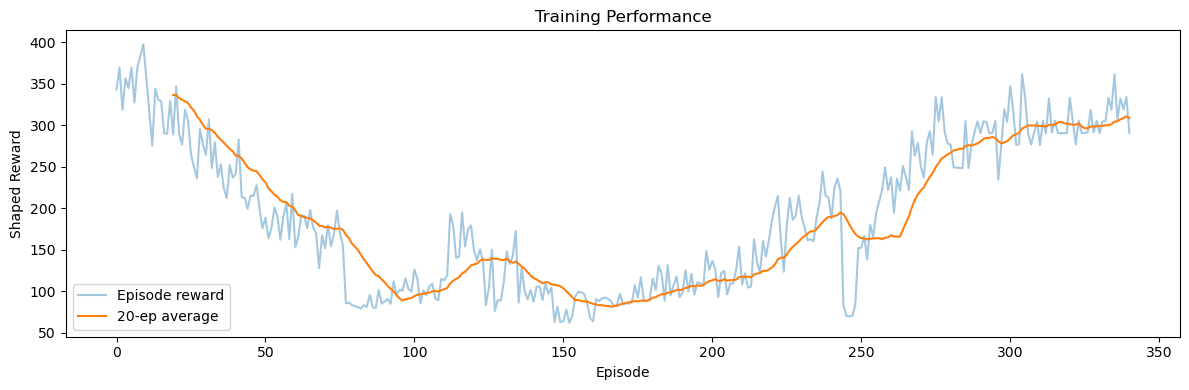

📊 Training curve saved → training_curve.png


In [10]:
plt.figure(figsize=(12, 4))
plt.plot(episode_rewards, alpha=0.4, label='Episode reward')
if len(episode_rewards) >= 20:
    smoothed = np.convolve(episode_rewards, np.ones(20)/20, mode='valid')
    plt.plot(range(19, len(episode_rewards)), smoothed, label='20-ep average')
plt.title('Training Performance')
plt.xlabel('Episode')
plt.ylabel('Shaped Reward')
plt.legend()
plt.tight_layout()
plt.savefig('training_curve.png')
plt.show()
print('📊 Training curve saved → training_curve.png')

## Step 11 — Live Demo 🎮
Loads the latest checkpoint and opens a window to watch your chicken play.

> **Note:** A small ε=0.05 is kept in the demo so the chicken doesn't get stuck in a deterministic loop.

In [ ]:
import os

LIVE_EPSILON  = 0.05
NUM_EPISODES  = 5   # change this to watch more episodes

# ── Load latest checkpoint ────────────────────────────────────────
checkpoint_files = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pth')])
if not checkpoint_files:
    raise ValueError('No checkpoints found! Run the training cell first.')

latest = os.path.join(CHECKPOINT_DIR, checkpoint_files[-1])
print(f'🎮 Loading: {latest}')

demo_model = CNN_DQN(n_actions=3).to(device)
ckpt = torch.load(latest, map_location=device)
demo_model.load_state_dict(ckpt['model_state_dict'])
demo_model.eval()

# ── Run episodes ──────────────────────────────────────────────────
env = gym.make('ALE/Freeway-v5', render_mode='human')
demo_rewards = []

for ep in range(NUM_EPISODES):
    obs, _ = env.reset()
    stack  = make_stack(obs)
    done   = False
    total  = 0

    while not done:
        state_tensor = to_tensor(to_state(stack))
        with torch.no_grad():
            q_values = demo_model(state_tensor)

        # Small epsilon prevents deterministic stuck loops
        if random.random() < LIVE_EPSILON:
            action = random.randint(0, 2)
        else:
            action = torch.argmax(q_values).item()

        obs, reward, terminated, truncated, _ = env.step(action)
        done   = terminated or truncated
        stack  = push_frame(stack, obs)
        total += reward

    demo_rewards.append(total)
    print(f'  Episode {ep+1} | Crossings: {int(total)}')

env.close()
print(f'\n🏁 Average crossings: {np.mean(demo_rewards):.2f}')

# ── Demo chart ───────────────────────────────────────────────────
plt.figure()
plt.bar(range(1, NUM_EPISODES+1), demo_rewards, color='steelblue')
plt.title('Live Demo — Crossings per Episode')
plt.xlabel('Episode')
plt.ylabel('Crossings')
plt.tight_layout()
plt.savefig('demo_results.png')
plt.show()
print('📊 Demo chart saved → demo_results.png')

🎮 Loading: checkpoints_cnn/cnn_model_step_90000.pth


objc[23775]: Class SDL_RumbleMotor is implemented in both /opt/anaconda3/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x30d728d40) and /opt/anaconda3/lib/python3.13/site-packages/ale_py/libSDL2-2.0.0.dylib (0x6813d8910). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[23775]: Class SDL_RumbleContext is implemented in both /opt/anaconda3/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x30d728d90) and /opt/anaconda3/lib/python3.13/site-packages/ale_py/libSDL2-2.0.0.dylib (0x6813d8960). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[23775]: Class SDLApplication is implemented in both /opt/anaconda3/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x30d728890) and /opt/anaconda3/lib/python3.13/site-packages/ale_py/libSDL2-2.0.0.dylib (0x6813d89b0). This may cause spurious casting failures and mysterious

In [1]:
import numpy as np

# Replace with your actual results from multiple episodes
scores_A = np.array([200, 210, 190, 205, 215, 198, 202, 207])
times_A = np.array([35, 33, 36, 34, 32, 35, 33, 34])

In [2]:
print("Model A Performance:\n")

print(f"Average Score: {np.mean(scores_A):.2f}")
print(f"Score Standard Deviation: {np.std(scores_A):.2f}")

print(f"Average Completion Time: {np.mean(times_A):.2f}")
print(f"Time Standard Deviation: {np.std(times_A):.2f}")

Model A Performance:

Average Score: 203.38
Score Standard Deviation: 7.21
Average Completion Time: 34.00
Time Standard Deviation: 1.22


In [3]:
from scipy import stats

def confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    margin = sem * stats.t.ppf((1 + confidence) / 2, len(data)-1)
    return mean - margin, mean + margin

ci_scores_A = confidence_interval(scores_A)
ci_times_A = confidence_interval(times_A)

print("\n95% Confidence Interval:")
print(f"Scores: {ci_scores_A}")
print(f"Completion Time: {ci_times_A}")


95% Confidence Interval:
Scores: (np.float64(196.93108901042672), np.float64(209.81891098957328))
Completion Time: (np.float64(32.905391669732886), np.float64(35.094608330267114))
